<a href="https://colab.research.google.com/github/perbik/cttc-ai-ml/blob/main/CTTC_AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
print("Current files:", os.listdir())

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

print("Extracted files:", os.listdir('data'))

# Load CSVs
train_df = pd.read_csv("data/twitter_training.csv")
val_df = pd.read_csv("data/twitter_validation.csv")

# Rename columns
train_df.columns = ["id", "entity", "sentiment", "text"]
val_df.columns = ["id", "entity", "sentiment", "text"]

# Drop missing values
train_df = train_df.dropna()
val_df = val_df.dropna()

Current files: ['.config', 'data', 'archive.zip', 'sample_data']
Extracted files: ['twitter_training.csv', 'twitter_validation.csv']


In [ ]:
le = LabelEncoder()
train_df['sentiment'] = le.fit_transform(train_df['sentiment'])
val_df['sentiment'] = le.transform(val_df['sentiment'])

sentiment_labels = le.classes_.tolist()
print("Sentiment Labels:", sentiment_labels)

Sentiment Labels: ['Irrelevant', 'Negative', 'Neutral', 'Positive']


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(val_df['text'])

y_train = train_df['sentiment']
y_test = val_df['sentiment']

In [ ]:
print("\nTraining Logistic Regression...")

lr_model = LogisticRegression(max_iter=200, n_jobs=-1)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=sentiment_labels))


Training Logistic Regression...

Logistic Regression Accuracy: 0.7447447447447447
              precision    recall  f1-score   support

  Irrelevant       0.76      0.61      0.68       171
    Negative       0.72      0.85      0.78       266
     Neutral       0.78      0.69      0.73       285
    Positive       0.73      0.79      0.76       277

    accuracy                           0.74       999
   macro avg       0.75      0.73      0.74       999
weighted avg       0.75      0.74      0.74       999



In [ ]:
print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=sentiment_labels))


Training Random Forest...

Random Forest Accuracy: 0.928928928928929
              precision    recall  f1-score   support

  Irrelevant       0.95      0.91      0.93       171
    Negative       0.91      0.96      0.94       266
     Neutral       0.95      0.91      0.93       285
    Positive       0.92      0.93      0.92       277

    accuracy                           0.93       999
   macro avg       0.93      0.93      0.93       999
weighted avg       0.93      0.93      0.93       999



In [ ]:
print("\nPreparing data for Neural Network...")

# Convert to dense ONLY here
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

print("Training Neural Network...")

model = keras.Sequential([
    keras.Input(shape=(X_train_dense.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(sentiment_labels), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_dense,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Predictions
y_pred_nn_probs = model.predict(X_test_dense)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)

# Evaluation
loss, accuracy = model.evaluate(X_test_dense, y_test)

print("\nNeural Network Accuracy:", accuracy)
print(classification_report(y_test, y_pred_nn, target_names=sentiment_labels))


Preparing data for Neural Network...
Training Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
925/925 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5950 - loss: 0.9795 - val_accuracy: 0.5065 - val_loss: 1.2460
Epoch 2/10
925/925 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7329 - loss: 0.6947 - val_accuracy: 0.4825 - val_loss: 1.4810
Epoch 3/10
925/925 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7982 - loss: 0.5386 - val_accuracy: 0.4706 - val_loss: 1.7416
Epoch 4/10
925/925 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8386 - loss: 0.4305 - val_accuracy: 0.4630 - val_loss: 2.0248
Epoch 5/10
925/925 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8656 - loss: 0.3596 - val_accuracy: 0.4610 - val_loss: 2.2763
Epoch 6/10
925/925 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8805 - loss: 0.3124 - val_accuracy: 0.4568 - val_loss: 2.5786
Epoch 7/10
925/925 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8920 - loss: 0.2790 - val_accuracy: 0.4567 - val_loss: 2.7894
Epoch 8/10
925/925 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8988 - loss: 0.2540 - val_accuracy:

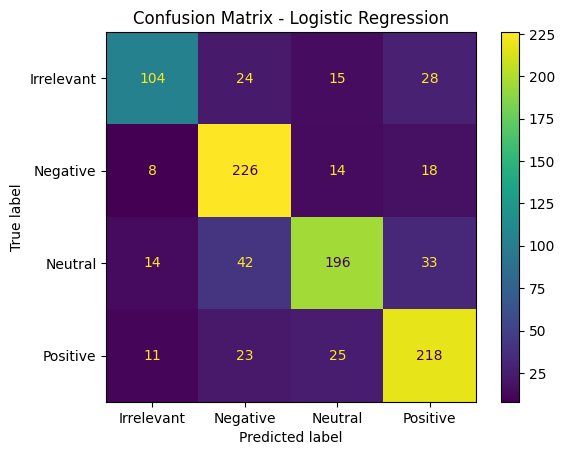

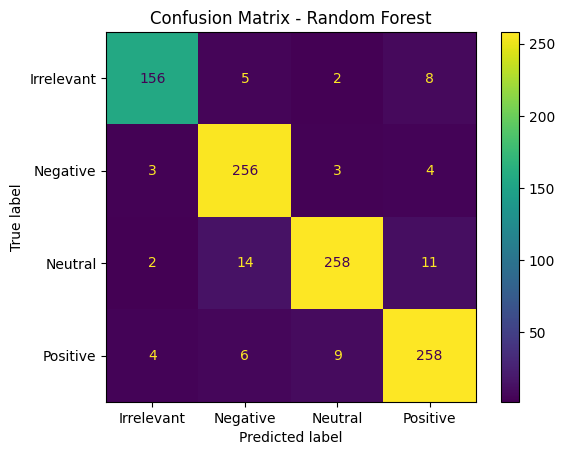

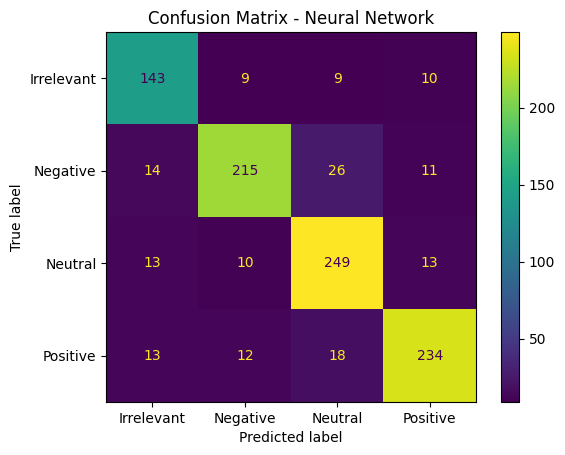

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=sentiment_labels)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=sentiment_labels)
plt.title("Confusion Matrix - Random Forest")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn, display_labels=sentiment_labels)
plt.title("Confusion Matrix - Neural Network")
plt.show()

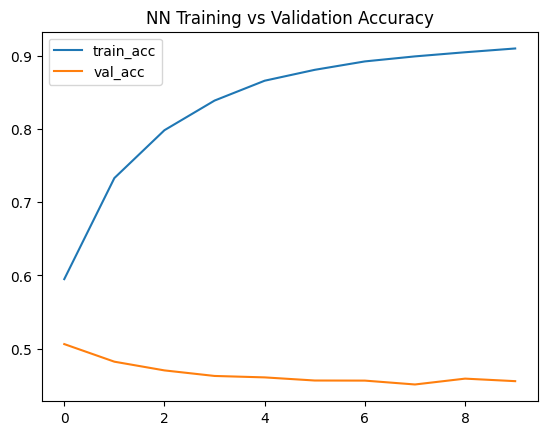

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("NN Training vs Validation Accuracy")
plt.show()